# Setup

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import string
from collections import Counter
from pathlib import Path
import random
import re

import torchinfo
import yaml
from bpe_tokenizer import SimpleBPE, SimpleBPEV2
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from dataset import IMDBConfig, IMDBData
from model import IMDBModelLP, IMDBModelLPPackedSeq, IMDBModelLPV2
from train import TrainerHighLevel

# Tell PyTorch it is safe to load your custom Config class
torch.serialization.add_safe_globals([IMDBConfig, IMDBData, IMDBModelLP])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

In [2]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.DEBUG)

In [3]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.INFO)

# 01 Data and model classes

## 01 IMDB Dataset

### 01 The first run and sample reviews

In [30]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000


In [28]:
# Let's look at some reviews and their corresponding labels from the training set

# Set indices for good and bad reviews
good_review = 1
bad_review = 16

# Print a good review and its label
print(f"Good Review (Index {good_review}):")
print(data.imdb_train_set[good_review][data.TEXT][0:100])  # Print the first 500 characters of the review
print(f"Label: {data.imdb_train_set[good_review][data.LABEL]} (1 = positive, 0 = negative)\n")

# Save the good review to a text file
good_review_text = data.imdb_train_set[good_review][data.TEXT]
with open("good_review.txt", "w") as f:
    f.write(good_review_text)

# Print a bad review and its label
print(f"Bad Review (Index {bad_review}):")
print(data.imdb_train_set[bad_review][data.TEXT][0:100])  #Print the first 500 characters of the review
print(f"Label: {data.imdb_train_set[bad_review][data.LABEL]} (1 = positive, 0 = negative)\n")

# Save the bad review to a text file
bad_review_text = data.imdb_train_set[bad_review][data.TEXT]
with open("bad_review.txt", "w") as f:
    f.write(bad_review_text)

Good Review (Index 1):
'The Rookie' was a wonderful movie about the second chances life holds for us and also puts an emoti
Label: 1 (1 = positive, 0 = negative)

Bad Review (Index 16):
Lillian Hellman's play, adapted by Dashiell Hammett with help from Hellman, becomes a curious projec
Label: 0 (1 = positive, 0 = negative)



### 02 BPE Tokenizer Training

In [31]:
# Create an instance of the IMDBData class with BPE tokenizer training
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000
DEBUG:imdb.dataset:===BPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:Training BPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']
DEBUG:imdb.dataset:Number of training reviews: 20000
DEBUG:imdb.dataset:BPE tokenizer training completed. Vocabulary size: 1000


In [ ]:
# Let's tokenize a sample review using the trained BPE tokenizer
some_review = "what an awesome movie! 😊"
# `encode` method returns tokens and their IDs, 
# but also much more information - see attributes of the returned object 
tokenized_review = data.bpe_tokenizer.encode(some_review) 

# Print the tokenized review
print(tokenized_review)

# Print the tokens and their corresponding IDs
print("Tokens:", tokenized_review.tokens)
print("Token IDs:", tokenized_review.ids)

Encoding(num_tokens=8, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
Tokens: ['what', 'an', 'aw', 'es', 'ome', 'movie', '!', '<unk>']
Token IDs: [303, 139, 373, 149, 240, 211, 4, 1]


In [41]:
# Let's explore some of the methods of the BPE tokenizer and how to use them
# Get a dictionary mapping each token to its ID
token_to_id = data.bpe_tokenizer.get_vocab()

# Print the first 5 tokens and their corresponding IDs
print(list(token_to_id.items())[:5])

# Get an index for a specific token
token = "what"
token_id = token_to_id.get(token)
print(f"Token: {token}, ID: {token_id}")
token_id2 = data.bpe_tokenizer.token_to_id(token)
print(f"Token: {token}, ID: {token_id}, ID2: {token_id2}")

# Get a token for a specific index
id = 303
token = data.bpe_tokenizer.id_to_token(id)
print(f"ID: {id}, Token: {token}")

# Decode the tokenized review back to the original text
decoded_review = data.bpe_tokenizer.decode(tokenized_review.ids)
print(f"Decoded Review: {decoded_review}")

[('mov', 193), ('together', 985), ('ingly', 999), ('dire', 426), ('woman', 859)]
Token: what, ID: 303
Token: what, ID: 303, ID2: 303
ID: 303, Token: what
Decoded Review: what an aw es ome movie !


In [44]:
# Create tokenizer with padding and truncation enabled
data_with_padding = IMDBData(config=IMDBConfig(), with_padding=True)

# Encode the first 3 reviews from train_reviews
bpe_encodings = data_with_padding.bpe_tokenizer.encode_batch(data_with_padding.train_reviews[:3])

# Print ids for the batch of reviews
bpe_batch_ids = torch.tensor([encoding.ids for encoding in bpe_encodings])
print("BPE Batch IDs:\n", bpe_batch_ids)

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000
DEBUG:imdb.dataset:===BPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:Training BPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']
DEBUG:imdb.dataset:Number of training reviews: 20000
DEBUG:imdb.dataset:BPE tokenizer training completed. Vocabulary size: 1000





BPE Batch IDs:
 tensor([[159, 402, 176, 246,  61, 782, 156, 737, 252,  42, 239,  51, 154, 460,
         917,  17, 272, 156, 737, 576, 215, 976, 275,  42, 199,  44, 554,  42,
         192, 585,  57, 160, 259, 170, 157, 143, 138, 159, 402,  11, 589, 152,
           5, 819, 168, 230,   5, 521, 924, 981, 962, 250,  61,  10,  60, 426,
         526, 959,  60, 138, 199, 150, 319,  15, 363, 141, 957, 694,  47, 696,
          61, 875, 138, 960, 337, 414, 140, 157, 385, 174, 433, 161, 221, 145,
         213,  17, 549,  15, 151,  10,  60,  55, 416, 146, 407, 144, 182, 303,
         151, 141,  17, 138, 547, 538, 528, 768,  54, 335,  42, 203,  44, 270,
          46, 153, 876, 141, 919, 233, 522, 172, 141, 719, 162, 807, 279,  17,
         138,  45,  66,  55, 188, 989, 156, 378, 698, 301, 296, 689, 212, 558,
         926, 148,  17,  44, 270,  46, 141,  47, 279, 302, 171, 152, 787,  15,
         153, 522, 172, 766, 205, 156, 234, 677, 161, 139, 513, 146, 370, 251,
         219, 162, 197, 162, 166,

### 03 BBPE Tokenizer Training

In [53]:
# Create an instance of the IMDBData class 
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000
DEBUG:imdb.dataset:===BPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:Training BPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']
DEBUG:imdb.dataset:BPE tokenizer training completed. Vocabulary size: 1000
DEBUG:imdb.dataset:===BBPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:Training BBPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']


DEBUG:imdb.dataset:BBPE tokenizer training completed. Vocabulary size: 1000


In [57]:
# Create some reviews to test the tokenizer
some_review = "what an awesome movie! 😊"

# Tokenize the review using the trained BBPE tokenizer
tokenized_review_bbpe = data.bbpe_tokenizer.encode(some_review)

# Print the tokenized review and its corresponding tokens and IDs
print(tokenized_review_bbpe)
print("Tokens:", tokenized_review_bbpe.tokens)
print("Token IDs:", tokenized_review_bbpe.ids)

# Detokize the tokenized review back to the original text using the BBPE tokenizer
decoded_review_bbpe = data.bbpe_tokenizer.decode(tokenized_review_bbpe.ids)
print(f"Decoded Review (BBPE): {decoded_review_bbpe}")

# Clean up the detokenized review by removing any special tokens (like the PAD token)
decoded_review_bbpe = decoded_review_bbpe.replace(" ", "").replace("Ġ", " ").strip()
print(f"Cleaned Decoded Review (BBPE): {decoded_review_bbpe}")

Encoding(num_tokens=12, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
Tokens: ['Ġwhat', 'Ġan', 'Ġaw', 'es', 'ome', 'Ġmovie', '!', 'Ġ', '<unk>', 'Ł', 'ĺ', '<unk>']
Token IDs: [354, 216, 561, 148, 244, 232, 2, 107, 1, 125, 119, 1]
Decoded Review (BBPE): Ġwhat Ġan Ġaw es ome Ġmovie ! Ġ Ł ĺ
Cleaned Decoded Review (BBPE): what an awesome movie! Łĺ


## 02 BPE Tokenizer from scratch

### 01 BPE Tokenizer Implementation: a few first runs

In [70]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=100)
bpe.fit(sample_text)

# Print the vocabulary learned by the BPE tokenizer
print(f"\nLearned Vocabulary size: {len(bpe.vocab)}")
print(f"Learned Vocabulary: {bpe.vocab}")  

print("\nLearned Merge Rules:")
for pair, merged in bpe.merges.items():
    print(f"{pair} -> '{merged}'")

# Test tokenization on unseen words
test_phrase = "lowest newer"
tokens = bpe.tokenize(test_phrase)
print(f"\nTokenizing '{test_phrase}':\n{tokens}")

INFO:imdb.bpe_tokenizer:Base vocabulary size: 11
INFO:imdb.bpe_tokenizer:Iterating to learn 89 merges...



Learned Vocabulary size: 26
Learned Vocabulary: ['t', 'i', 'o', 'l', 'w', 'd', '</w>', 'r', 'n', 's', 'e', 'lo', 'low', 'es', 'est', 'est</w>', 'low</w>', 'lowe', 'lower', 'lower</w>', 'ne', 'new', 'newest</w>', 'wi', 'wid', 'widest</w>']

Learned Merge Rules:
('l', 'o') -> 'lo'
('lo', 'w') -> 'low'
('e', 's') -> 'es'
('es', 't') -> 'est'
('est', '</w>') -> 'est</w>'
('low', '</w>') -> 'low</w>'
('low', 'e') -> 'lowe'
('lowe', 'r') -> 'lower'
('lower', '</w>') -> 'lower</w>'
('n', 'e') -> 'ne'
('ne', 'w') -> 'new'
('new', 'est</w>') -> 'newest</w>'
('w', 'i') -> 'wi'
('wi', 'd') -> 'wid'
('wid', 'est</w>') -> 'widest</w>'

Tokenizing 'lowest newer':
['low', 'est</w>', 'new', 'e', 'r', '</w>']


In [66]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest higher faster taller maker baker"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=100)
bpe.fit(sample_text)

print("\nLearned Merge Rules:")
for pair, merged in bpe.merges.items():
    print(f"{pair} -> '{merged}'")

# Test tokenization on unseen words
test_phrase = "lowest newer"
tokens = bpe.tokenize(test_phrase)
print(f"\nTokenizing '{test_phrase}':\n{tokens}")

Base vocabulary size: 18
Iterating to learn 82 merges...

Learned Merge Rules:
('e', 'r') -> 'er'
('er', '</w>') -> 'er</w>'
('s', 't') -> 'st'
('l', 'o') -> 'lo'
('lo', 'w') -> 'low'
('e', 'st') -> 'est'
('est', '</w>') -> 'est</w>'
('a', 'k') -> 'ak'
('ak', 'er</w>') -> 'aker</w>'
('low', '</w>') -> 'low</w>'
('low', 'er</w>') -> 'lower</w>'
('n', 'e') -> 'ne'
('ne', 'w') -> 'new'
('new', 'est</w>') -> 'newest</w>'
('w', 'i') -> 'wi'
('wi', 'd') -> 'wid'
('wid', 'est</w>') -> 'widest</w>'
('h', 'i') -> 'hi'
('hi', 'g') -> 'hig'
('hig', 'h') -> 'high'
('high', 'er</w>') -> 'higher</w>'
('f', 'a') -> 'fa'
('fa', 'st') -> 'fast'
('fast', 'er</w>') -> 'faster</w>'
('t', 'a') -> 'ta'
('ta', 'l') -> 'tal'
('tal', 'l') -> 'tall'
('tall', 'er</w>') -> 'taller</w>'
('m', 'aker</w>') -> 'maker</w>'
('b', 'aker</w>') -> 'baker</w>'

Tokenizing 'lowest newer':
['low', 'est</w>', 'new', 'er</w>']


In [9]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest higher faster taller maker baker"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=100)
bpe.fit(sample_text)

# Print token to index mapping
print(f"\nToken to Index Mapping: {list(bpe.token_to_index.items())[:10]}")

# Print index to token mapping
print(f"Index to Token Mapping: {list(bpe.index_to_token.items())[:10]}")

# Test tokenization on unseen words
test_phrase = "lowest newer"
test_phrase_encoded = bpe.encode(test_phrase)
print(f"\nTokenizing '{test_phrase}':\n{test_phrase_encoded}")
test_phrase_decoded = bpe.decode(test_phrase_encoded)
print(f"Decoded '{test_phrase}':\n{test_phrase_decoded}")

DEBUG:imdb.bpe_tokenizer:  Fitting BPE tokenizer to text with target vocab size 100...
DEBUG:imdb.bpe_tokenizer:  Base vocabulary size: 18
DEBUG:imdb.bpe_tokenizer:  Iterating to learn 82 merges...



Token to Index Mapping: [('o', 0), ('</w>', 1), ('b', 2), ('g', 3), ('d', 4), ('a', 5), ('m', 6), ('s', 7), ('h', 8), ('l', 9)]
Index to Token Mapping: [(0, 'o'), (1, '</w>'), (2, 'b'), (3, 'g'), (4, 'd'), (5, 'a'), (6, 'm'), (7, 's'), (8, 'h'), (9, 'l')]

Tokenizing 'lowest newer':
[22, 24, 30, 19]
Decoded 'lowest newer':
lowestnewer


### 02 BPE Tokenizer Implementation: digging deeper

In [19]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=20)
bpe.fit(sample_text)

DEBUG:imdb.bpe_tokenizer:  Fitting BPE tokenizer to text with target vocab size 20...
DEBUG:imdb.bpe_tokenizer:  Found ['low', 'lower', 'newest', 'widest'] words in the corpus.
DEBUG:imdb.bpe_tokenizer:  Corpus words split into characters: [['l', 'o', 'w', '</w>'], ['l', 'o', 'w', 'e', 'r', '</w>'], ['n', 'e', 'w', 'e', 's', 't', '</w>'], ['w', 'i', 'd', 'e', 's', 't', '</w>']]
DEBUG:imdb.bpe_tokenizer:  Unique characters in the corpus: {'o', '</w>', 'd', 's', 'l', 'i', 'e', 'n', 'w', 't', 'r'}
DEBUG:imdb.bpe_tokenizer:  Initial vocabulary (characters): ['o', '</w>', 'd', 's', 'l', 'i', 'e', 'n', 'w', 't', 'r']
DEBUG:imdb.bpe_tokenizer:  Base vocabulary size: 11
DEBUG:imdb.bpe_tokenizer:  Iterating to learn 9 merges...
DEBUG:imdb.bpe_tokenizer:  
===Iteration 1/9===
DEBUG:imdb.bpe_tokenizer:  Pairs frequency: Counter({('l', 'o'): 2, ('o', 'w'): 2, ('w', 'e'): 2, ('e', 's'): 2, ('s', 't'): 2, ('t', '</w>'): 2, ('w', '</w>'): 1, ('e', 'r'): 1, ('r', '</w>'): 1, ('n', 'e'): 1, ('e', 'w'):

In [26]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest lwo"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=20)

# Get the initial corpus for debugging
initial_corpus = bpe._get_initial_corpus(sample_text)

# Merge the vocabulary on a simple pair
pair = ('l', 'o')
merged_corpus = bpe._merge_vocab(initial_corpus, pair)

DEBUG:imdb.bpe_tokenizer:  Initial raw words from text: ['low', 'lower', 'newest', 'widest', 'lwo']
DEBUG:imdb.bpe_tokenizer:  Initial corpus words split into characters: [['l', 'o', 'w', '</w>'], ['l', 'o', 'w', 'e', 'r', '</w>'], ['n', 'e', 'w', 'e', 's', 't', '</w>'], ['w', 'i', 'd', 'e', 's', 't', '</w>'], ['l', 'w', 'o', '</w>']]
DEBUG:imdb.bpe_tokenizer:  ===MERGING VOCAB===
DEBUG:imdb.bpe_tokenizer:  Merging pair: ('l', 'o')
DEBUG:imdb.bpe_tokenizer:  New merged token: lo
DEBUG:imdb.bpe_tokenizer:  ---Processing word: ['l', 'o', 'w', '</w>']---
DEBUG:imdb.bpe_tokenizer:  Found pair ('l', 'o') in word ['l', 'o', 'w', '</w>'] at index 0. Merging into 'lo'.
DEBUG:imdb.bpe_tokenizer:  New word after merging: ['lo']
DEBUG:imdb.bpe_tokenizer:  New word after appending character: ['lo', 'w']
DEBUG:imdb.bpe_tokenizer:  New word after appending character: ['lo', 'w', '</w>']
DEBUG:imdb.bpe_tokenizer:  Final new word after processing: ['lo', 'w', '</w>']
DEBUG:imdb.bpe_tokenizer:  ---Proc

In [27]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=20)
bpe.fit(sample_text)

DEBUG:imdb.bpe_tokenizer:  Fitting BPE tokenizer to text with target vocab size 20...
DEBUG:imdb.bpe_tokenizer:  Initial raw words from text: ['low', 'lower', 'newest', 'widest']
DEBUG:imdb.bpe_tokenizer:  Initial corpus words split into characters: [['l', 'o', 'w', '</w>'], ['l', 'o', 'w', 'e', 'r', '</w>'], ['n', 'e', 'w', 'e', 's', 't', '</w>'], ['w', 'i', 'd', 'e', 's', 't', '</w>']]
DEBUG:imdb.bpe_tokenizer:  Unique characters in the corpus: {'o', '</w>', 'd', 's', 'l', 'i', 'e', 'n', 'w', 't', 'r'}
DEBUG:imdb.bpe_tokenizer:  Initial vocabulary (characters): ['o', '</w>', 'd', 's', 'l', 'i', 'e', 'n', 'w', 't', 'r']
DEBUG:imdb.bpe_tokenizer:  Base vocabulary size: 11
DEBUG:imdb.bpe_tokenizer:  Iterating to learn 9 merges...
DEBUG:imdb.bpe_tokenizer:  
===Iteration 1/9===
DEBUG:imdb.bpe_tokenizer:  Pairs frequency: Counter({('l', 'o'): 2, ('o', 'w'): 2, ('w', 'e'): 2, ('e', 's'): 2, ('s', 't'): 2, ('t', '</w>'): 2, ('w', '</w>'): 1, ('e', 'r'): 1, ('r', '</w>'): 1, ('n', 'e'): 1, (

### 03 BPE Tokenizer Implementation: `"<w>"` token

In [33]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest higher faster taller maker baker"
)

# We want a final vocabulary size of 20
bpe = SimpleBPE(vocab_size=100)
bpe.fit(sample_text)

# Print token to index mapping
# print(f"\nToken to Index Mapping: {list(bpe.token_to_index.items())[:10]}")

# Print index to token mapping
# print(f"Index to Token Mapping: {list(bpe.index_to_token.items())[:10]}")

# Test tokenization on unseen words
test_phrase = "lowest newer"
test_phrase_tokens = bpe.tokenize(test_phrase)
print(f"Tokenizing '{test_phrase}': {test_phrase_tokens}")
test_phrase_encoded = bpe.encode(test_phrase)
print(f"Encoded '{test_phrase}': {test_phrase_encoded}")
test_phrase_decoded = bpe.decode(test_phrase_encoded)
print(f"Decoded '{test_phrase}': {test_phrase_decoded}")

Tokenizing 'lowest newer': ['low', 'est</w>', 'new', 'er</w>']
Encoded 'lowest newer': [22, 24, 30, 19]
Decoded 'lowest newer': lowestnewer


In [36]:
# Sample toy corpus with repeating subword patterns
sample_text = (
    "low lower newest widest higher faster taller maker baker"
)

# We want a final vocabulary size of 20
bpe = SimpleBPEV2(vocab_size=100)
bpe.fit(sample_text)

# Print token to index mapping
# print(f"\nToken to Index Mapping: {list(bpe.token_to_index.items())[:10]}")

# Print index to token mapping
# print(f"Index to Token Mapping: {list(bpe.index_to_token.items())[:10]}")

# Test tokenization on unseen words
test_phrase = "lowest newer"
test_phrase_tokens = bpe.tokenize(test_phrase)
print(f"Tokenizing '{test_phrase}': {test_phrase_tokens}")
test_phrase_encoded = bpe.encode(test_phrase)
print(f"Encoded '{test_phrase}': {test_phrase_encoded}")
test_phrase_decoded = bpe.decode(test_phrase_encoded)
print(f"Decoded '{test_phrase}': {test_phrase_decoded}")

Tokenizing 'lowest newer': ['low', 'est', 'new', 'er']
Encoded 'lowest newer': [20, 21, 26, 17]
Decoded 'lowest newer': low est new er


### 04 BPE Tokenizer Implementation: adding the `"<w>"` token to HuggingFace BPE Tokenizer

In [5]:
# Create an instance of the IMDBData class with BPE tokenizer training
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 20000
DEBUG:imdb.dataset:  Number of validation samples (after split): 5000
DEBUG:imdb.dataset:  ===BPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:  Training BPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']
DEBUG:imdb.dataset:  Decoder added to BPE tokenizer with suffix '</w>'
DEBUG:imdb.dataset:  BPE tokenizer training completed. Vocabulary size: 1000
DEBUG:imdb.dataset:  ===BBPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:  Training BBPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']


DEBUG:imdb.dataset:  BBPE tokenizer training completed. Vocabulary size: 1000


In [6]:
# Let's tokenize a sample review using the trained BPE tokenizer
some_review = "what an awesome movie! 😊"

# Encode the review using the BPE tokenizer
tokenized_review = data.bpe_tokenizer.encode(some_review)
print(f"Tokenized Review: {tokenized_review}")
print(f"Tokens: {tokenized_review.tokens}")
print(f"Token IDs: {tokenized_review.ids}")

# Decode the tokenized review back to the original text
decoded_review = data.bpe_tokenizer.decode(tokenized_review.ids)
print(f"Decoded Review: {decoded_review}")

Tokenized Review: Encoding(num_tokens=8, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
Tokens: ['what</w>', 'an</w>', 'a', 'we', 'some</w>', 'movie</w>', '!</w>', '<unk>']
Token IDs: [438, 295, 42, 614, 442, 337, 185, 1]
Decoded Review: what an awesome movie !


In [9]:
# Check for presence of special tokens in BPE tokenizer vocabulary
token_to_id = data.bpe_tokenizer.get_vocab()
print(f"Pad Token ID: {token_to_id.get(data.PAD_TOKEN)}")
print(f"Unknown Token ID: {token_to_id.get(data.UNK_TOKEN)}")

Pad Token ID: 0
Unknown Token ID: 1


### 05 Matching the "Whitespace" Pre-tokenizer

In [11]:
# Let's check the new pre-tokenizer
text = "Hello, world!"
raw_words = re.findall(r"\w+|[^\w\s]", text.lower())
print(raw_words)

['hello', ',', 'world', '!']


## 03 BBPE Tokenizer from scratch

### 01 `_get_initial_corpus` method

In [13]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 20000
DEBUG:imdb.dataset:  Number of validation samples (after split): 5000
DEBUG:imdb.dataset:  ===BPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:  Training BPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']
DEBUG:imdb.dataset:  Decoder added to BPE tokenizer with suffix '</w>'
DEBUG:imdb.dataset:  BPE tokenizer training completed. Vocabulary size: 1000
DEBUG:imdb.dataset:  ===BBPE TOKENIZER TRAINING===
DEBUG:imdb.dataset:  Training BBPE tokenizer with vocab size: 1000 and special tokens: ['<pad>', '<unk>']


DEBUG:imdb.dataset:  BBPE tokenizer training completed. Vocabulary size: 1000


In [17]:
# Extract some review
review_index = 1  # Change this index to extract a different review
review_text = data.imdb_train_set[review_index][data.TEXT]
print(f"Review (Index {review_index}):")
print(review_text[0:200])  # Print the first 200 characters of the review

# Create a lossles regex pattern to match words and punctuation
pattern = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?[^\s\w]+|\s+(?!\S)|\s+""")
raw_chunks = pattern.findall(review_text.lower())
print(f"Raw Chunks: {raw_chunks[:10]}")  # Print the first 10 chunks for inspection

# Print review and chunks into a file 
with open("review_chunks.txt", "w") as f:
    f.write(f"Review (Index {review_index}):\n")
    f.write(review_text + "\n\n")  # Write the full review
    f.write(f"Raw Chunks:\n{raw_chunks}")  # Write the full list of chunks for inspection

Review (Index 1):
'The Rookie' was a wonderful movie about the second chances life holds for us and also puts an emotional thought over the audience, making them realize that your dreams can come true. If you loved 'Re
Raw Chunks: ["'t", 'he', ' rookie', "'", ' was', ' a', ' wonderful', ' movie', ' about', ' the']


In [29]:
corpus_words = []
for i, chunk in enumerate(raw_chunks[:3]):
    print(f"===Iteration {i}===")
    # 2. Encode the chunk into UTF-8 bytes
    byte_chunk = chunk.encode("utf-8")
    print(f"byte_chunk: {byte_chunk}")  # Print the hex representation of each byte in the chunk
    
    # 3. Convert that byte sequence into a list of individual byte objects.
    # bites([b]) creates a single-byte object like b'h' out of the integer.
    individual_bytes = [bytes([b]) for b in byte_chunk]
    print(f"individual_bytes: {individual_bytes}")  # Print the list of individual byte objects
    corpus_words.append(individual_bytes)
    print(f"corpus_words: {corpus_words}")  # Print the list of lists of individual byte objects

===Iteration 0===
byte_chunk: b"'t"
individual_bytes: [b"'", b't']
corpus_words: [[b"'", b't']]
===Iteration 1===
byte_chunk: b'he'
individual_bytes: [b'h', b'e']
corpus_words: [[b"'", b't'], [b'h', b'e']]
===Iteration 2===
byte_chunk: b' rookie'
individual_bytes: [b' ', b'r', b'o', b'o', b'k', b'i', b'e']
corpus_words: [[b"'", b't'], [b'h', b'e'], [b' ', b'r', b'o', b'o', b'k', b'i', b'e']]


## 04 Pre-trained BPE Tokenizer

In [38]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 20000
DEBUG:imdb.dataset:  Number of validation samples (after split): 5000
DEBUG:imdb.dataset:  ===LOADING PRETRAINED BBPE TOKENIZER (gpt2)===
DEBUG:imdb.dataset:  Using local tokenizer found at: datasets/tokenizers/gpt2/tokenizer.json


In [48]:
# Extract the first 3 reviews from the training set
train_reviews = data.train_reviews[:3]

# Print the length of each review and the first 50 characters for inspection
print("===Train Reviews:===")
for i, review in enumerate(train_reviews):
    print(f"Review {i} Length: {len(review)}")
    print(f"Review {i} Content (first 50 chars): {review[:50]}")

# Encode the first 3 reviews using the BBPE tokenizer
bpe_encodings = data.bbpe_tokenizer.encode_batch(train_reviews)

# Print length of each encoded review and the first 10 token IDs for inspection
print("\n===Encoded Reviews:===")
for i, encoding in enumerate(bpe_encodings):
    print(f"Encoded Review {i} Length: {len(encoding.ids)}")
    print(f"Encoded Review {i} Token IDs (first 10): {encoding.ids[:10]}")

# Print the full encodings into a file for inspection
with open("printouts/encoded_reviews.txt", "w") as f:
    for i, encoding in enumerate(bpe_encodings):
        f.write(f"Encoded Review {i} Length: {len(encoding.ids)}\n")
        f.write(f"Encoded Review {i} Token IDs: {encoding.ids}\n\n")

# Decode the first 10 token IDs of each encoded review back to text
print("\n===Decoded Reviews (first 10 token IDs):===")
for i, encoding in enumerate(bpe_encodings):
    decoded_review = data.bbpe_tokenizer.decode(encoding.ids[:10])
    print(f"Decoded Review {i} (first 10 token IDs): {decoded_review}")

===Train Reviews:===
Review 0 Length: 843
Review 0 Content (first 50 chars): stage adaptations often have a major fault. they o
Review 1 Length: 370
Review 1 Content (first 50 chars): 'the rookie' was a wonderful movie about the secon
Review 2 Length: 912
Review 2 Content (first 50 chars): ok,but does that make this a good movie?well,not r

===Encoded Reviews:===
Encoded Review 0 Length: 231
Encoded Review 0 Token IDs (first 10): [14247, 35030, 1690, 423, 257, 1688, 8046, 13, 484, 1690]
Encoded Review 1 Length: 231
Encoded Review 1 Token IDs (first 10): [470, 258, 12302, 6, 373, 257, 7932, 3807, 546, 262]
Encoded Review 2 Length: 231
Encoded Review 2 Token IDs (first 10): [482, 11, 4360, 857, 326, 787, 428, 257, 922, 3807]

===Decoded Reviews (first 10 token IDs):===
Decoded Review 0 (first 10 token IDs): stage adaptations often have a major fault. they often
Decoded Review 1 (first 10 token IDs): 'the rookie' was a wonderful movie about the
Decoded Review 2 (first 10 token IDs): ok,bu

In [49]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 20000
DEBUG:imdb.dataset:  Number of validation samples (after split): 5000
DEBUG:imdb.dataset:  ===LOADING PRETRAINED BBPE TOKENIZER (gpt2)===
DEBUG:imdb.dataset:  Using local tokenizer found at: datasets/tokenizers/gpt2/tokenizer.json


In [50]:
# Create loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

DEBUG:imdb.dataset:  ===DATA LOADERS CREATED===
DEBUG:imdb.dataset:  Train loader: 40 batches, 20000 samples
DEBUG:imdb.dataset:  Validation loader: 10 batches, 5000 samples


## 05 Custom `collate_fn` for BPE Tokenizer

In [3]:
# Create an instance of the IMDBData class with BPE tokenizer training
data = IMDBData(config=IMDBConfig())

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 20000
DEBUG:imdb.dataset:  Number of validation samples (after split): 5000
DEBUG:imdb.dataset:  ===LOADING PRETRAINED BBPE TOKENIZER (gpt2)===
DEBUG:imdb.dataset:  Using local tokenizer found at: datasets/tokenizers/gpt2/tokenizer.json


In [ ]:
# Let's check what data.imdb_data dataset returns
next_data = next(iter(data.imdb_train_set))
print(f"Type of next_data: {type(next_data)}") # Returns <class 'dict'>
print(f"Keys in next_data: {next_data.keys()}") # Returns dict_keys(['text', 'label'])

Type of next_data: <class 'dict'>
Keys in next_data: dict_keys(['text', 'label'])


In [20]:
# Create loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

# Get a batch of data from the training loader
torch.manual_seed(42)  # For reproducibility
batch = next(iter(train_loader))

# Print the type of the batch, its keys, and the shapes of 'input_ids' and 'labels'
print(f"\nBatch Type: {type(batch)}")
print(f"Batch Keys: {batch.keys()}")
print(f"Input IDs Shape: {batch['input_ids'].shape}")
print(f"Labels Shape: {batch['labels'].shape}")

DEBUG:imdb.dataset:  ===DATA LOADERS CREATED===
DEBUG:imdb.dataset:  Train loader: 40 batches, 20000 samples
DEBUG:imdb.dataset:  Validation loader: 10 batches, 5000 samples
DEBUG:imdb.dataset:  ===COLLATE_FN===
DEBUG:imdb.dataset:  Batch type: <class 'list'>, Batch size: 512
DEBUG:imdb.dataset:  First item type: <class 'dict'>, Keys: dict_keys(['text', 'label'])
DEBUG:imdb.dataset:  First item text length: 667, First item label: 1
DEBUG:imdb.dataset:  Encodings type: <class 'list'>, Number of encodings: 512
DEBUG:imdb.dataset:  First encoding type: <class 'tokenizers.Encoding'>
DEBUG:imdb.dataset:  First encoding Length: 500 First Label: 1



Batch Type: <class 'dict'>
Batch Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
Input IDs Shape: torch.Size([512, 500])
Labels Shape: torch.Size([512])


In [8]:
type(batch), batch.keys(), batch['input_ids'].shape, batch['labels'].shape

(dict,
 dict_keys(['input_ids', 'attention_mask', 'labels']),
 torch.Size([512, 500]),
 torch.Size([512]))

## 06 `IMDBModelLP` class

### 01 The last output of the top GRU layer

In [2]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

# Create data loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

In [3]:
# Extract a batch of data from the training loader
torch.manual_seed(42)  # For reproducibility
batch = next(iter(train_loader))
input_ids = batch['input_ids']
labels = batch['labels']

In [4]:
# Create an instance of the IMDBModelLP class with the configuration and data
model = IMDBModelLP(config=data.config, data=data)

In [5]:
# Run a forward pass through the model to get logits
logits = model(input_ids) 

### 02 `padding_idx` in the Embedding layer

In [7]:
# Create an instance of the IMDBModelLP class with the configuration and data
model = IMDBModelLP(config=data.config, data=data)

DEBUG:imdb.model:  ===MODEL CREATION===
DEBUG:imdb.model:  Model initialized with vocab_size: 50259
DEBUG:imdb.model:  Model hyperparameters: hidden_dim=256, num_layers=2, embedding_dim=256, dropout=0.2
DEBUG:imdb.model:  Embedding layer created with embedding_dim: 256
DEBUG:imdb.model:  Embedding layer dimensions: torch.Size([50259, 256])
DEBUG:imdb.model:  GRU layer created with hidden_dim: 256, num_layers: 2, dropout: 0.2
DEBUG:imdb.model:  LayerNorm created with hidden_dim: 256
DEBUG:imdb.model:  Output Linear layer created mapping hidden_dim: 256 to num_classes: 2


In [8]:
# Run a forward pass through the model to get logits
logits = model(input_ids) 

DEBUG:imdb.model:  ===FORWARD PASS===
DEBUG:imdb.model:  ---Input shapes---
DEBUG:imdb.model:  (1) Batch size: 512, Sequence length: 500, Embedding dimension: 256
DEBUG:imdb.model:  (1) Forward pass input shape (x): torch.Size([512, 500])
DEBUG:imdb.model:  ---Embeddings shapes---
DEBUG:imdb.model:  (1) Embeddings output shape: torch.Size([512, 500, 256])
DEBUG:imdb.model:  ---Embeddings padding---
DEBUG:imdb.model:  (DIAGNOSTIC) Max value in padding embeddings: 0.000000
DEBUG:imdb.model:  (DIAGNOSTIC) SUCCESS: Padding tokens are zeroed out by Embedding layer.
DEBUG:imdb.model:  ---GRU outputs---
DEBUG:imdb.model:  (2) Hidden dimension: 256
DEBUG:imdb.model:  (2) GRU output shape: torch.Size([512, 500, 256])
DEBUG:imdb.model:  (2) GRU last hidden state shape: torch.Size([2, 512, 256])
DEBUG:imdb.model:  (2) Sample GRU outputs (first batch, last timestep):
tensor([-0.0364,  0.0218,  0.0957, -0.0467, -0.0011], grad_fn=<SliceBackward0>)
DEBUG:imdb.model:  (2) Sample final outputs (first b

In [9]:
# Create an instance of the IMDBModelLP class with the configuration and data
model = IMDBModelLP(config=data.config, data=data)

DEBUG:imdb.model:  ===MODEL CREATION===
DEBUG:imdb.model:  Model initialized with vocab_size: 50259
DEBUG:imdb.model:  Model hyperparameters: hidden_dim=256, num_layers=2, embedding_dim=256, dropout=0.2
DEBUG:imdb.model:  Embedding layer created with embedding_dim: 256
DEBUG:imdb.model:  Embedding layer dimensions: torch.Size([50259, 256])
DEBUG:imdb.model:  GRU layer created with hidden_dim: 256, num_layers: 2, dropout: 0.2
DEBUG:imdb.model:  LayerNorm created with hidden_dim: 256
DEBUG:imdb.model:  Output Linear layer created mapping hidden_dim: 256 to num_classes: 2


In [10]:
# Run a forward pass through the model to get logits
logits = model(input_ids) 

DEBUG:imdb.model:  ===FORWARD PASS===
DEBUG:imdb.model:  ---Input shapes---
DEBUG:imdb.model:  (1) Batch size: 512, Sequence length: 500, Embedding dimension: 256
DEBUG:imdb.model:  (1) Forward pass input shape (x): torch.Size([512, 500])
DEBUG:imdb.model:  ---Embeddings shapes---
DEBUG:imdb.model:  (1) Embeddings output shape: torch.Size([512, 500, 256])
DEBUG:imdb.model:  ---Embeddings padding---
DEBUG:imdb.model:  (DIAGNOSTIC) Max value in padding embeddings: 0.000000
DEBUG:imdb.model:  (DIAGNOSTIC) SUCCESS: Padding tokens are zeroed out by Embedding layer.
DEBUG:imdb.model:  ---GRU outputs---
DEBUG:imdb.model:  (2) Hidden dimension: 256
DEBUG:imdb.model:  (2) GRU output shape: torch.Size([512, 500, 256])
DEBUG:imdb.model:  (2) GRU last hidden state shape: torch.Size([2, 512, 256])
DEBUG:imdb.model:  (2) Sample GRU outputs (first batch, last timestep):
tensor([ 0.0298,  0.0681,  0.1046, -0.0115,  0.0945], grad_fn=<SliceBackward0>)
DEBUG:imdb.model:  (2) Sample final outputs (first b

### 03 Attention mask

In [11]:
attention_mask = batch[data.ATTENTION_MASK]

In [14]:
attention_mask.shape, input_ids.shape

(torch.Size([512, 500]), torch.Size([512, 500]))

In [13]:
attention_mask[0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
(input_ids[0] > 0).to(torch.int32)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### 04 Packed sequences (1)

In [ ]:
sequences = torch.tensor([[1, 2, 0, 0], [5, 6, 7, 8]])

In [23]:
sequences

tensor([[1, 2, 0, 0],
        [5, 6, 7, 8]])

In [24]:
packed = pack_padded_sequence(sequences, lengths=(2, 4), 
                              enforce_sorted=False, batch_first=True)

In [25]:
packed

PackedSequence(data=tensor([5, 1, 6, 2, 7, 8]), batch_sizes=tensor([2, 2, 1, 1]), sorted_indices=tensor([1, 0]), unsorted_indices=tensor([1, 0]))

### 05 Packed sequences (2)

In [ ]:
# Create an instance of the IMDBData class
data = IMDBData(config=IMDBConfig())

# Create data loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

# Extract a batch of data from the training loader
torch.manual_seed(42)  # For reproducibility
batch = next(iter(train_loader))
input_ids = batch['input_ids']
labels = batch['labels']
attention_mask = batch[data.ATTENTION_MASK]

# Create an instance of the IMDBModelLP class with the configuration and data
model = IMDBModelLPPackedSeq(config=data.config, data=data)

DEBUG:imdb.dataset:  ===DATASET LOADED===
DEBUG:imdb.dataset:  Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:  Number of training samples (original dataset): 1000
DEBUG:imdb.dataset:  Number of test samples (original dataset): 500
DEBUG:imdb.dataset:  ===DATASET SPLIT===
DEBUG:imdb.dataset:  Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:  Number of training samples (after split): 800
DEBUG:imdb.dataset:  Number of validation samples (after split): 200
DEBUG:imdb.dataset:  ===LOADING PRETRAINED BBPE TOKENIZER (gpt2)===
DEBUG:imdb.dataset:  Using local tokenizer found at: datasets/tokenizers/gpt2/tokenizer.json
DEBUG:imdb.dataset:  ===DATA LOADERS CREATED===
DEBUG:imdb.dataset:  Train loader: 2 batches, 800 samples
DEBUG:imdb.dataset:  Validation loader: 1 batches, 200 samples
DEBUG:imdb.dataset:  ===COLLATE_FN===
DEBUG:imdb.dataset:  Batch type: <class 'list'>, Batch size: 512
DEBUG:imdb.dataset:  First item type: <class 'dict'>, Keys: dict_keys(['

In [30]:
# Run a forward pass through the model to get logits
logits = model(input_ids, attention_mask=attention_mask) 

DEBUG:imdb.model:  ===FORWARD PASS (PACKED)===
DEBUG:imdb.model:  ---Input shapes---
DEBUG:imdb.model:  Batch size: 512, Sequence length: 500, Embedding dimension: 256
DEBUG:imdb.model:  Forward pass input shape (x): torch.Size([512, 500])
DEBUG:imdb.model:  ---Embeddings shapes---
DEBUG:imdb.model:  (1) Embeddings output shape: torch.Size([512, 500, 256])
DEBUG:imdb.model:  ---Packing sequences---
DEBUG:imdb.model:  (2) Attention mask shape: torch.Size([512, 500])
DEBUG:imdb.model:  (2) Lengths tensor: tensor([171, 500, 258, 390,  56])
DEBUG:imdb.model:  ---GRU outputs---
DEBUG:imdb.model:  (3) Hidden dimension: 256
DEBUG:imdb.model:  (3) GRU output shape: torch.Size([133142, 256])
DEBUG:imdb.model:  (3) GRU last hidden state shape: torch.Size([2, 512, 256])
DEBUG:imdb.model:  (3) Sample GRU outputs (first batch, last timestep):
tensor([-0.0025, -0.0071,  0.0082, -0.0144, -0.0003], grad_fn=<SliceBackward0>)
DEBUG:imdb.model:  (3) Sample final outputs (first batch):
tensor([-0.0156, -0

# 02 Training

## 01 Packed sequences

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) an

🚀 Using hardware accelerator: mps:0


/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
Metric val_loss improved. New best score: 0.700


Epoch   1 | Train Loss: 2.0217 | Train Acc: 0.1746 | Val Loss: 0.6997 | Val Acc: 0.6195


Metric val_loss improved by 0.699 >= min_delta = 0.0. New best score: 0.000


...

Epoch   4 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.000


Epoch   5 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch   6 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch   7 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


Monitored metric val_loss did not improve in the last 3 records. Best score: 0.000. Signaling Trainer to stop.


Epoch   8 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000

🛑 Early Stopping triggered at epoch 8

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 5):
├─ Train Loss: 0.0000
├─ Train Acc:  1.0000
├─ Val Loss:   0.0000
└─ Val Acc:    1.0000


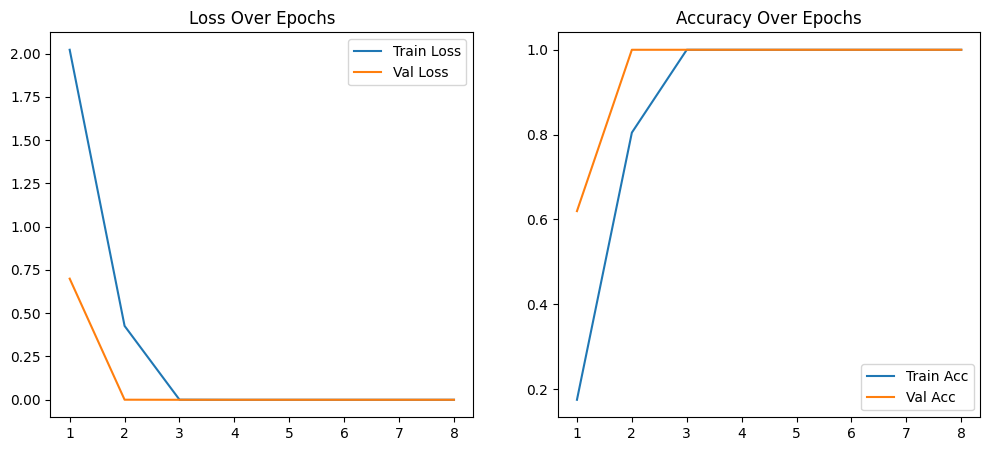

In [2]:
# Specify the config file
config_name = "base_config"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, data_limit=1024)

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

In [ ]:
# Specify the config file
config_name = "base_config"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, data_limit=1024, device='cpu')

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/Users

🚀 Using hardware accelerator: cpu


Metric val_loss improved. New best score: 0.231


Epoch   1 | Train Loss: 0.8285 | Train Acc: 0.6020 | Val Loss: 0.2305 | Val Acc: 0.9171


Metric val_loss improved by 0.230 >= min_delta = 0.0. New best score: 0.000


Epoch   2 | Train Loss: 0.1646 | Train Acc: 0.9463 | Val Loss: 0.0003 | Val Acc: 1.0000


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config_down exists and is not empty.


🚀 Using hardware accelerator: mps:0


Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_step

Epoch   1 | Train Loss: 1.0376 | Train Acc: 0.5079 | Val Loss: 1.0464 | Val Acc: 0.4634


Metric val_loss improved by 0.148 >= min_delta = 0.0. New best score: 0.898


Epoch   2 | Train Loss: 0.9800 | Train Acc: 0.4945 | Val Loss: 0.8984 | Val Acc: 0.5512


Metric val_loss improved by 0.019 >= min_delta = 0.0. New best score: 0.879
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch   3 | Train Loss: 0.8274 | Train Acc: 0.5214 | Val Loss: 0.8794 | Val Acc: 0.5268

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 3):
├─ Train Loss: 0.8274
├─ Train Acc:  0.5214
├─ Val Loss:   0.8794
└─ Val Acc:    0.5268


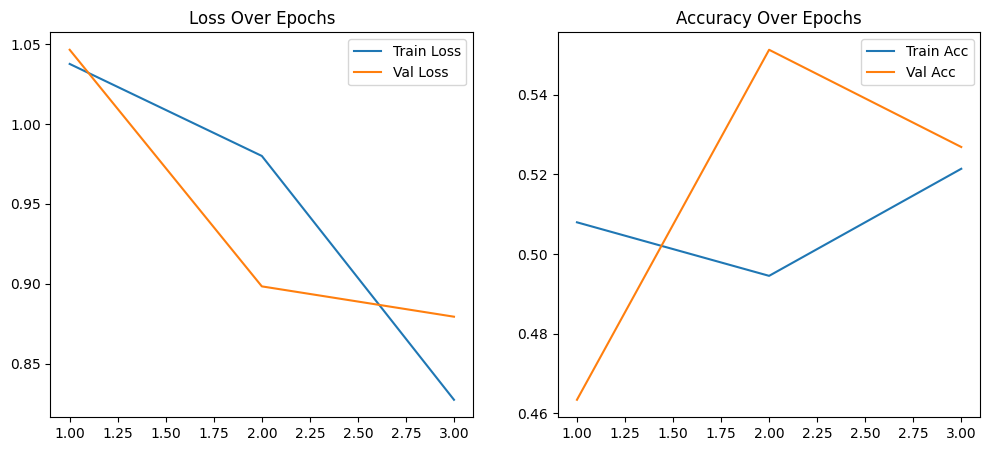

In [4]:
# Specify the config file
config_name = "base_config_down"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=1024,
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config_down exists and is not empty.


🚀 Using hardware accelerator: mps:0


Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_ste

Epoch   1 | Train Loss: 0.8828 | Train Acc: 0.5138 | Val Loss: 0.6996 | Val Acc: 0.5508


Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 0.672


Epoch   2 | Train Loss: 0.6647 | Train Acc: 0.5952 | Val Loss: 0.6716 | Val Acc: 0.5913


`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch   3 | Train Loss: 0.6180 | Train Acc: 0.6621 | Val Loss: 0.6764 | Val Acc: 0.5820

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 2):
├─ Train Loss: 0.6647
├─ Train Acc:  0.5952
├─ Val Loss:   0.6716
└─ Val Acc:    0.5913


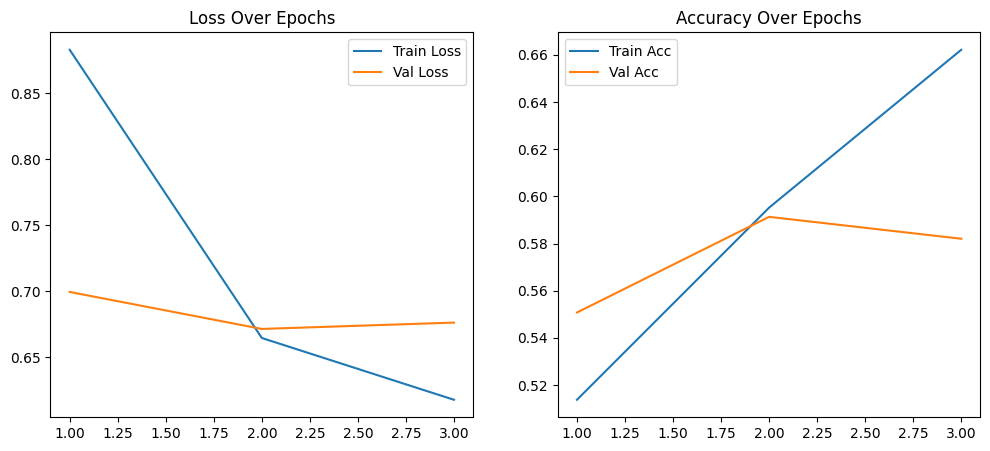

In [5]:
# Specify the config file
config_name = "base_config_down"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=10240,
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

## 02 No packing, but with attention mask

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config exists and is not empty.


🚀 Using hardware accelerator: mps:0


Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_step

Epoch   1 | Train Loss: 1.1629 | Train Acc: 0.4188 | Val Loss: 0.0254 | Val Acc: 0.9951


Metric val_loss improved by 0.025 >= min_delta = 0.0. New best score: 0.000


...

Epoch   4 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.000


Epoch   5 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


`Trainer.fit` stopped: `max_epochs=5` reached.



✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 5):
├─ Train Loss: 0.0000
├─ Train Acc:  1.0000
├─ Val Loss:   0.0000
└─ Val Acc:    1.0000


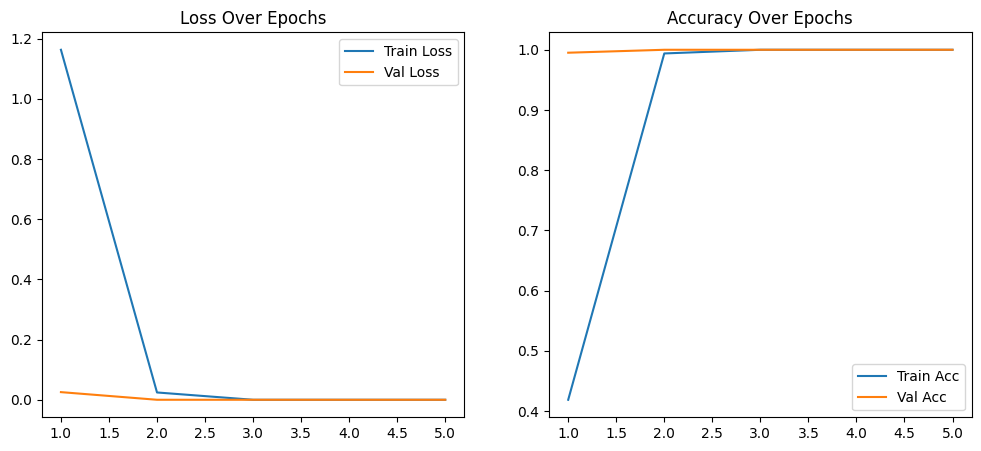

In [3]:
# Specify the config file
config_name = "base_config"

# Instantiate using IMDBModelLP
trainer = TrainerHighLevel(
    config_name=config_name,
    device='auto', 
    data_limit=1024, 
    model_class=IMDBModelLPV2
)

# Fit the model using the trainer (Can use "auto" device safely!)
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

## 03 Downgraded model

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config_down exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpe

🚀 Using hardware accelerator: mps:0


Metric val_loss improved. New best score: 0.554


Epoch   1 | Train Loss: 0.7494 | Train Acc: 0.5897 | Val Loss: 0.5543 | Val Acc: 0.7024


Metric val_loss improved by 0.437 >= min_delta = 0.0. New best score: 0.118


...

Epoch   8 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.000


Epoch   9 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.000
`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch  10 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 10):
├─ Train Loss: 0.0000
├─ Train Acc:  1.0000
├─ Val Loss:   0.0000
└─ Val Acc:    1.0000


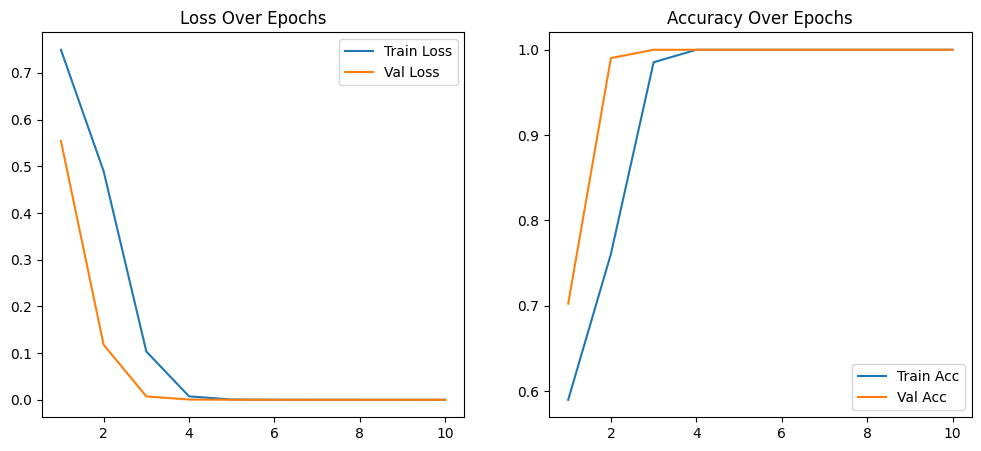

In [5]:
# Specify the config file
config_name = "base_config_down"

# Instantiate using IMDBModelLP
trainer = TrainerHighLevel(
    config_name=config_name,
    device='auto', 
    data_limit=1024, 
    model_class=IMDBModelLPV2
)

# Fit the model using the trainer (Can use "auto" device safely!)
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

In [7]:
20 * 512

10240

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config_down exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpe

🚀 Using hardware accelerator: mps:0


/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
Metric val_loss improved. New best score: 0.830


Epoch   1 | Train Loss: 0.9458 | Train Acc: 0.5040 | Val Loss: 0.8302 | Val Acc: 0.5371


Metric val_loss improved by 0.140 >= min_delta = 0.0. New best score: 0.690


Epoch   2 | Train Loss: 0.7462 | Train Acc: 0.5537 | Val Loss: 0.6905 | Val Acc: 0.5757


Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.664


Epoch   3 | Train Loss: 0.6518 | Train Acc: 0.6160 | Val Loss: 0.6643 | Val Acc: 0.6060
Epoch   4 | Train Loss: 0.5625 | Train Acc: 0.7052 | Val Loss: 0.7109 | Val Acc: 0.6313
Epoch   5 | Train Loss: 0.4209 | Train Acc: 0.8071 | Val Loss: 0.7983 | Val Acc: 0.6401


Monitored metric val_loss did not improve in the last 3 records. Best score: 0.664. Signaling Trainer to stop.


Epoch   6 | Train Loss: 0.2848 | Train Acc: 0.8795 | Val Loss: 0.9544 | Val Acc: 0.6553

🛑 Early Stopping triggered at epoch 6

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 3):
├─ Train Loss: 0.6518
├─ Train Acc:  0.6160
├─ Val Loss:   0.6643
└─ Val Acc:    0.6060


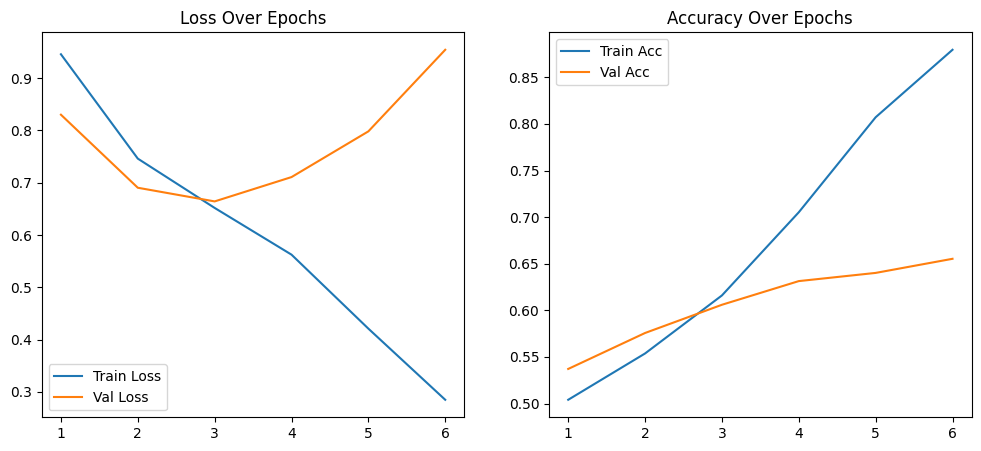

In [3]:
# Specify the config file
config_name = "base_config_down"

# Instantiate using IMDBModelLP
trainer = TrainerHighLevel(
    config_name=config_name,
    device='auto', 
    data_limit=10240, 
    model_class=IMDBModelLPV2
)

# Fit the model using the trainer (Can use "auto" device safely!)
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

## 04 Packed sequences (2)

### 01 Downgraded model with regularization

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


🚀 Using hardware accelerator: mps:0


Loading `train_dataloader` to estimate number of stepping batches.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_ste

Epoch   1 | Train Loss: 1.0881 | Train Acc: 0.4929 | Val Loss: 0.9246 | Val Acc: 0.5000


Metric val_loss improved by 0.225 >= min_delta = 0.0. New best score: 0.700


...

Epoch   3 | Train Loss: 0.6733 | Train Acc: 0.5867 | Val Loss: 0.6716 | Val Acc: 0.5864


Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.668


Epoch   4 | Train Loss: 0.5718 | Train Acc: 0.6997 | Val Loss: 0.6681 | Val Acc: 0.6567
Epoch   5 | Train Loss: 0.4450 | Train Acc: 0.7935 | Val Loss: 0.8330 | Val Acc: 0.6440


Monitored metric val_loss did not improve in the last 2 records. Best score: 0.668. Signaling Trainer to stop.


Epoch   6 | Train Loss: 0.3024 | Train Acc: 0.8729 | Val Loss: 0.8946 | Val Acc: 0.6748

🛑 Early Stopping triggered at epoch 6

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 4):
├─ Train Loss: 0.5718
├─ Train Acc:  0.6997
├─ Val Loss:   0.6681
└─ Val Acc:    0.6567


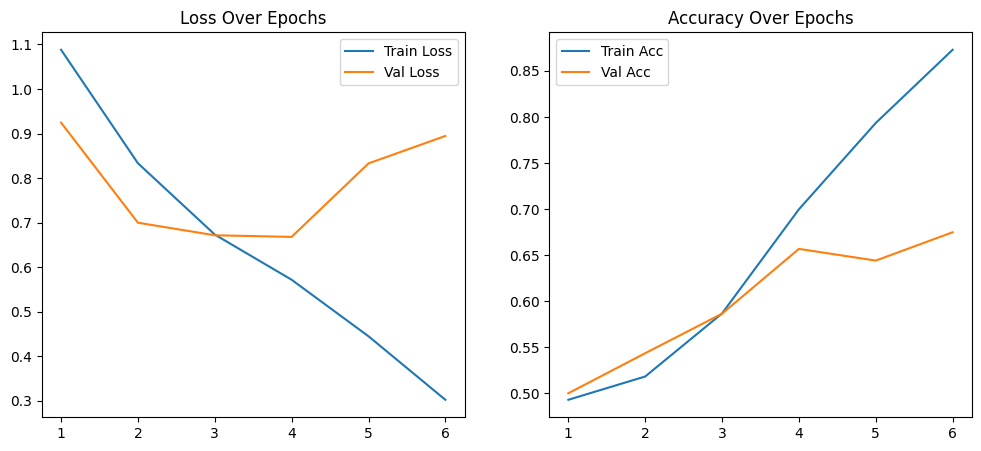

In [6]:
# Specify the config file
config_name = "base_config_down_reg"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=10240,
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/01-artificial-int/14-hands-on-geron/14-nlp-with-rnns/02-sentiment-analysis/checkpoints/base_config_down_reg exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.


🚀 Using hardware accelerator: mps:0


/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/iliarudiak/Library/Mobile Documents/com~apple~CloudDocs/_working/2026/env/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/Users/iliarudia

Epoch   1 | Train Loss: 0.9056 | Train Acc: 0.5157 | Val Loss: 0.7334 | Val Acc: 0.5388


Metric val_loss improved by 0.069 >= min_delta = 0.0. New best score: 0.665


...

Epoch   3 | Train Loss: 0.6139 | Train Acc: 0.6612 | Val Loss: 0.6184 | Val Acc: 0.6630


Metric val_loss improved by 0.158 >= min_delta = 0.0. New best score: 0.460


Epoch   4 | Train Loss: 0.4422 | Train Acc: 0.7954 | Val Loss: 0.4601 | Val Acc: 0.7874
Epoch   5 | Train Loss: 0.2786 | Train Acc: 0.8885 | Val Loss: 0.5008 | Val Acc: 0.7958


Monitored metric val_loss did not improve in the last 2 records. Best score: 0.460. Signaling Trainer to stop.


Epoch   6 | Train Loss: 0.1876 | Train Acc: 0.9316 | Val Loss: 0.6120 | Val Acc: 0.7940

🛑 Early Stopping triggered at epoch 6

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 4):
├─ Train Loss: 0.4422
├─ Train Acc:  0.7954
├─ Val Loss:   0.4601
└─ Val Acc:    0.7874


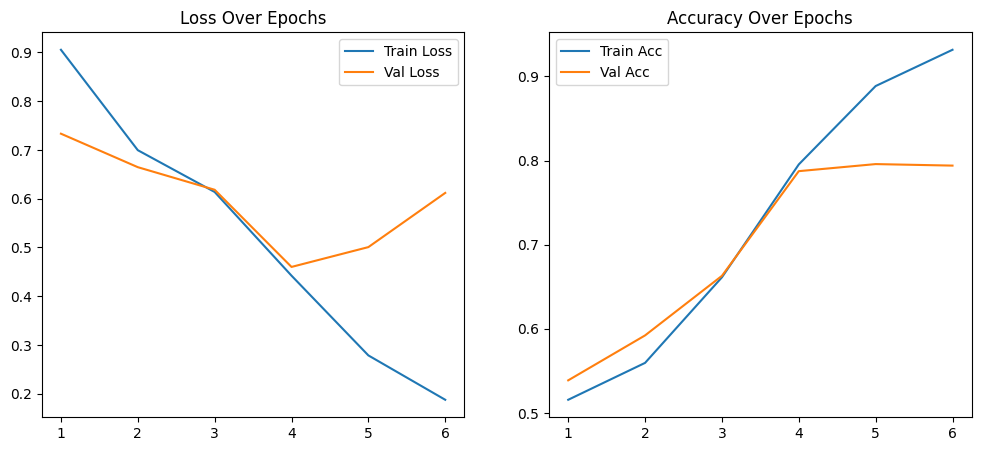

In [8]:
# Specify the config file
config_name = "base_config_down_reg"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=None, # Use the full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()